# Intuition for a Linear State-Space Neural System

This notebook uses `Simulator` and `Illustrator` to build hands-on intuition for a
discrete-time linear Gaussian state-space model. Each section answers one question:

1. **How do observed signals change over time?** — Sections 1–2
2. **How do different input patterns affect observations?** — Sections 3–6
3. **Are some signals more informative than others?** — Section 7
4. **What is easy to observe, and what seems hidden?** — Sections 8–9

> **To explore a different system:** edit only the *System Configuration* cell below.
> Every subsequent cell reads from `sim` and adapts automatically.

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, ".")

from Simulator import (
    Simulator, default_neural_system,
    zero_input, pulse_input, sinusoidal_input,
    random_input, channel_sweep_input, mixed_input,
    controllability_matrix, observability_matrix, matrix_rank,
)
from Illustrator import Illustrator
import importlib, Illustrator as _ill_mod
importlib.reload(_ill_mod)

%matplotlib inline
plt.rcParams["figure.dpi"] = 110

## System Configuration

Edit **this cell only** to change the system. The rest of the notebook adapts automatically.

**Option A** — default neural system (change `obs_dim` freely)  
**Option B** — supply your own matrices `A, B, C, Q, R`

In [2]:
# ── Option A: default neural system ──────────────────────────────────────
sim = default_neural_system(seed=42, obs_dim=16)

# ── Option B: custom system (uncomment and fill in) ──────────────────────
# n, m, p = 3, 1, 8          # state, input, obs dimensions
# A = ...                    # (n, n) state transition
# B = ...                    # (n, m) input matrix
# C = ...                    # (p, n) observation matrix
# Q = 1e-3 * np.eye(n)       # process noise covariance
# R_obs = 1e-2 * np.eye(p)   # observation noise covariance
# sim = Simulator(A, B, C, Q, R_obs, seed=42)

T        = 120   # timesteps per trial
R_trials = 30    # number of independent trials

print(f'System: state_dim={sim.state_dim}, input_dim={sim.input_dim}, obs_dim={sim.obs_dim}')
print(f'T={T}, R_trials={R_trials}')

System: state_dim=4, input_dim=2, obs_dim=16
T=120, R_trials=30


---
## 1  Meet the System

Before running any simulation, inspect the mathematical skeleton.
The matrix **A** determines how the hidden state evolves; its eigenvalues set the
oscillation frequencies and decay rates. **C** projects those states into the neurons
you can actually record.

In [3]:
print('=== Dimensions ===')
print(f'  n (state) = {sim.state_dim},  m (input) = {sim.input_dim},  p (obs) = {sim.obs_dim}')

print('\n=== State transition matrix A ===')
print(np.round(sim.A, 4))

print('\n=== Input matrix B ===')
print(np.round(sim.B, 4))

nrows = min(4, sim.obs_dim)
print(f'\n=== Observation matrix C (first {nrows} of {sim.obs_dim} rows) ===')
print(np.round(sim.C[:nrows], 4))

=== Dimensions ===
  n (state) = 4,  m (input) = 2,  p (obs) = 16

=== State transition matrix A ===
[[ 0.9225 -0.2997  0.      0.    ]
 [ 0.2997  0.9225  0.      0.    ]
 [ 0.05    0.      0.98    0.    ]
 [ 0.      0.05    0.      0.75  ]]

=== Input matrix B ===
[[1.  0. ]
 [0.  1. ]
 [0.5 0. ]
 [0.  0.5]]

=== Observation matrix C (first 4 of 16 rows) ===
[[ 0.3047 -1.04    0.7505  0.9406]
 [-1.951  -1.3022  0.1278 -0.3162]
 [-0.0168 -0.853   0.8794  0.7778]
 [ 0.066   1.1272  0.4675 -0.8593]]


In [4]:
eigvals_A = np.linalg.eigvals(sim.A)

print('Eigenvalues of A:')
for i, lam in enumerate(eigvals_A):
    mag   = abs(lam)
    angle = np.angle(lam)
    if abs(angle) > 1e-10:
        desc = f'period ≈ {abs(2 * np.pi / angle):.1f} steps  (oscillatory)'
    else:
        hl = np.log(0.5) / np.log(mag) if 0 < mag < 1 else float('inf')
        desc = f'half-life ≈ {hl:.1f} steps  (pure decay)'
    print(f'  λ{i} = {lam.real:+.4f}{lam.imag:+.4f}j   |λ| = {mag:.4f}   {desc}')

print(f'\nAll |λ| < 1 (stable): {np.all(np.abs(eigvals_A) < 1)}')

# Natural oscillation period — used in later sections
osc = eigvals_A[(np.abs(eigvals_A.imag) > 1e-10) & (eigvals_A.imag > 0)]
nat_period = int(round(abs(2 * np.pi / np.angle(osc[0])))) if len(osc) > 0 else T // 4
print(f'\nNatural oscillation period: ~{nat_period} steps')

Eigenvalues of A:
  λ0 = +0.9800+0.0000j   |λ| = 0.9800   half-life ≈ 34.3 steps  (pure decay)
  λ1 = +0.7500+0.0000j   |λ| = 0.7500   half-life ≈ 2.4 steps  (pure decay)
  λ2 = +0.9225+0.2997j   |λ| = 0.9700   period ≈ 20.0 steps  (oscillatory)
  λ3 = +0.9225-0.2997j   |λ| = 0.9700   period ≈ 20.0 steps  (oscillatory)

All |λ| < 1 (stable): True

Natural oscillation period: ~20 steps


=== Controllability ===
  rank = 4 / 4  →  FULLY CONTROLLABLE

=== Observability ===
  rank = 4 / 4  →  FULLY OBSERVABLE


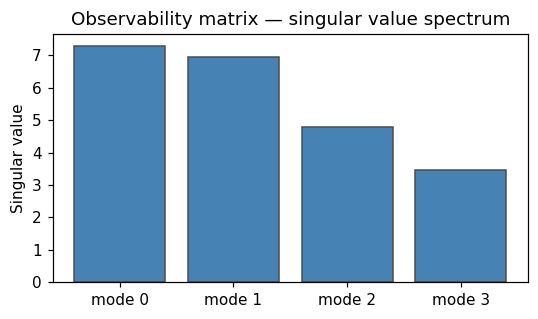

Condition number: 2.10  (larger → some modes harder to recover)


In [5]:
Wc = controllability_matrix(sim.A, sim.B)
Wo = observability_matrix(sim.A, sim.C)
rank_c = matrix_rank(Wc)
rank_o = matrix_rank(Wo)

print('=== Controllability ===')
print(f'  rank = {rank_c} / {sim.state_dim}  →  {"FULLY CONTROLLABLE" if rank_c == sim.state_dim else "NOT FULLY CONTROLLABLE"}')

print('\n=== Observability ===')
print(f'  rank = {rank_o} / {sim.state_dim}  →  {"FULLY OBSERVABLE" if rank_o == sim.state_dim else "NOT FULLY OBSERVABLE"}')

_, s_obs, _ = np.linalg.svd(Wo)
n = sim.state_dim
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(range(n), s_obs[:n], color='steelblue', edgecolor='0.3')
ax.set_xticks(range(n))
ax.set_xticklabels([f'mode {i}' for i in range(n)])
ax.set_ylabel('Singular value')
ax.set_title('Observability matrix — singular value spectrum')
plt.tight_layout(); plt.show()
print(f'Condition number: {s_obs[0]/s_obs[n-1]:.2f}  (larger → some modes harder to recover)')

**What to notice:**
- Each complex-conjugate eigenvalue pair in A corresponds to an oscillatory mode;
  real eigenvalues are pure decay. The magnitude `|λ|` sets the decay per step.
- *Fully observable* means every state can in principle be inferred from y — but the
  singular value spectrum tells you *how easily*. A large condition number means some
  state directions are much harder to recover than others.
- The fast-decaying mode (smallest `|λ|`) will contribute little to the time-averaged
  signal, making it effectively hard to observe in noisy data.

---
## 2  Free Dynamics — Zero Input

Run the system from its initial condition with no input. This isolates A's effect:
the initial state decays and oscillates purely according to the eigenstructure above.

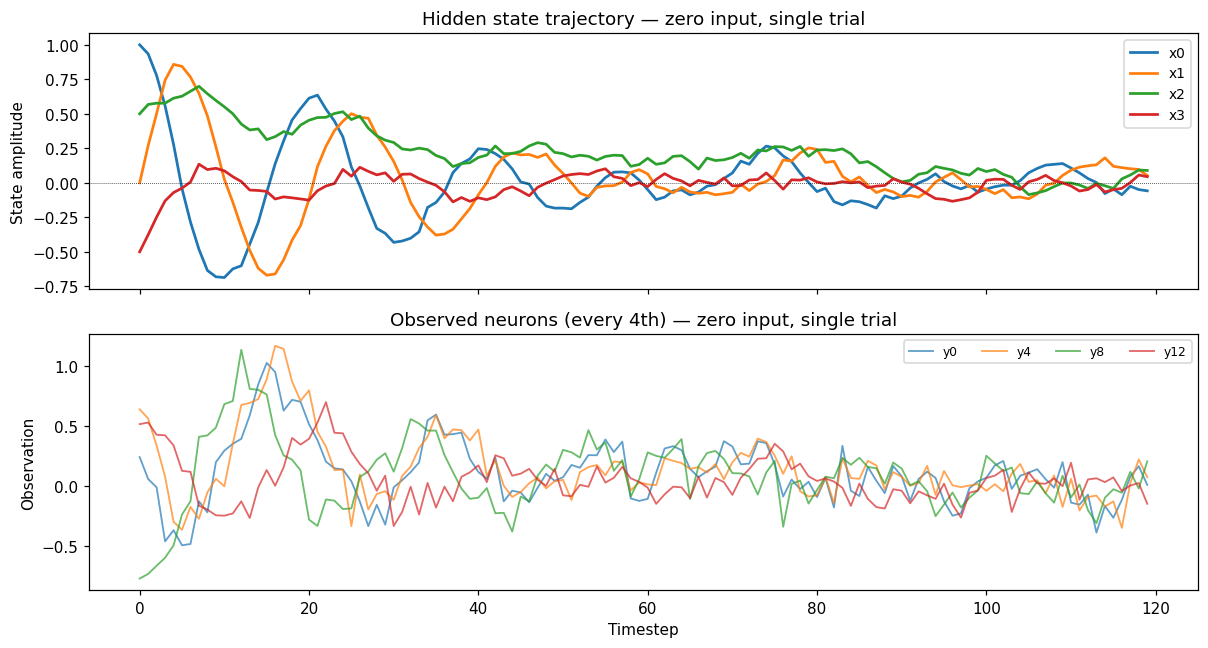

In [6]:
U_zero      = zero_input(T, sim.input_dim)
result_zero = sim.simulate(T, U=U_zero)
x_zero      = result_zero['x'][:-1]   # (T, state_dim)
y_zero_1    = result_zero['y']         # (T, obs_dim) — single trial

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

for i in range(sim.state_dim):
    axes[0].plot(x_zero[:, i], label=f'x{i}', linewidth=1.8)
axes[0].set_ylabel('State amplitude')
axes[0].set_title('Hidden state trajectory — zero input, single trial')
axes[0].legend(fontsize=9); axes[0].axhline(0, color='k', lw=0.5, ls=':')

step = max(1, sim.obs_dim // 4)
for ni in range(0, sim.obs_dim, step):
    axes[1].plot(y_zero_1[:, ni], alpha=0.7, lw=1.2, label=f'y{ni}')
axes[1].set_ylabel('Observation')
axes[1].set_xlabel('Timestep')
axes[1].set_title(f'Observed neurons (every {step}th) — zero input, single trial')
axes[1].legend(fontsize=8, ncol=4)
plt.tight_layout(); plt.show()

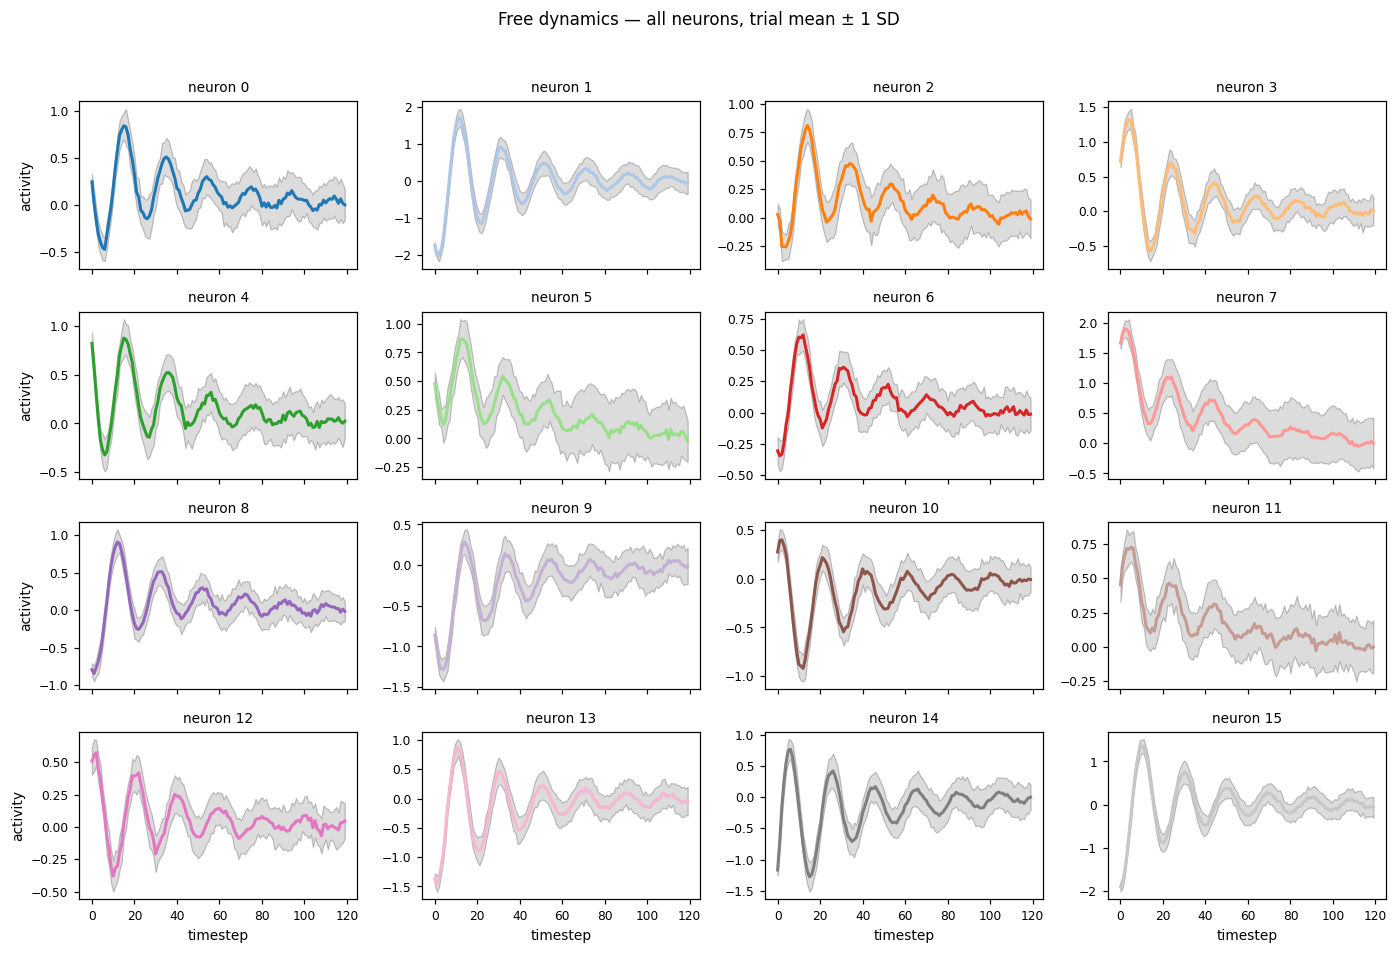

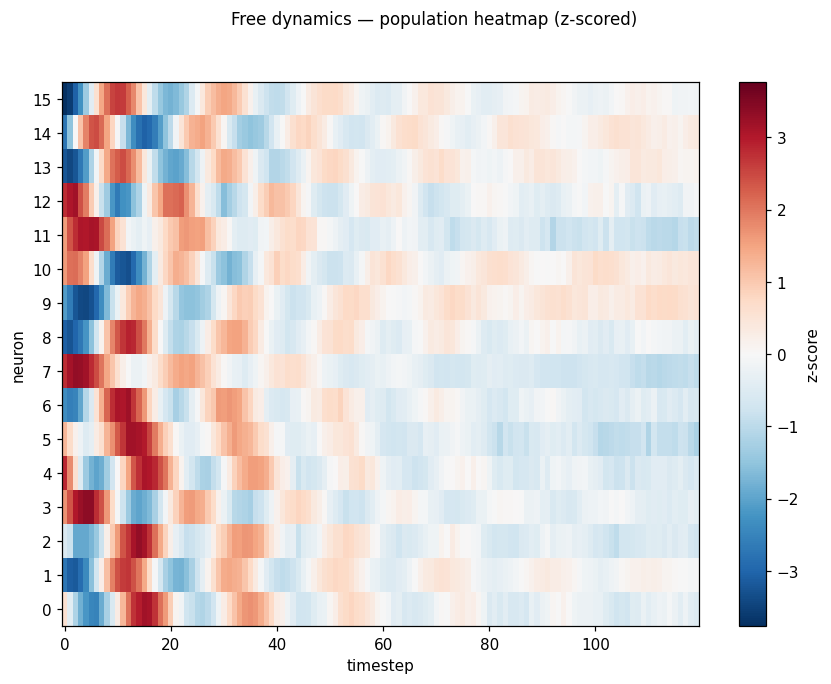

C:\Users\sassa\AppData\Local\Temp\ipykernel_36836\1063110266.py:13: UserWarning: max_lag=40 exceeds T//4=30; the longest lag uses only 80 pairs per trial and the tail of the ACF may be unreliable.
  fig = ill_zero.plot_autocorrelation(max_lag=max_lag, mode='heatmap',


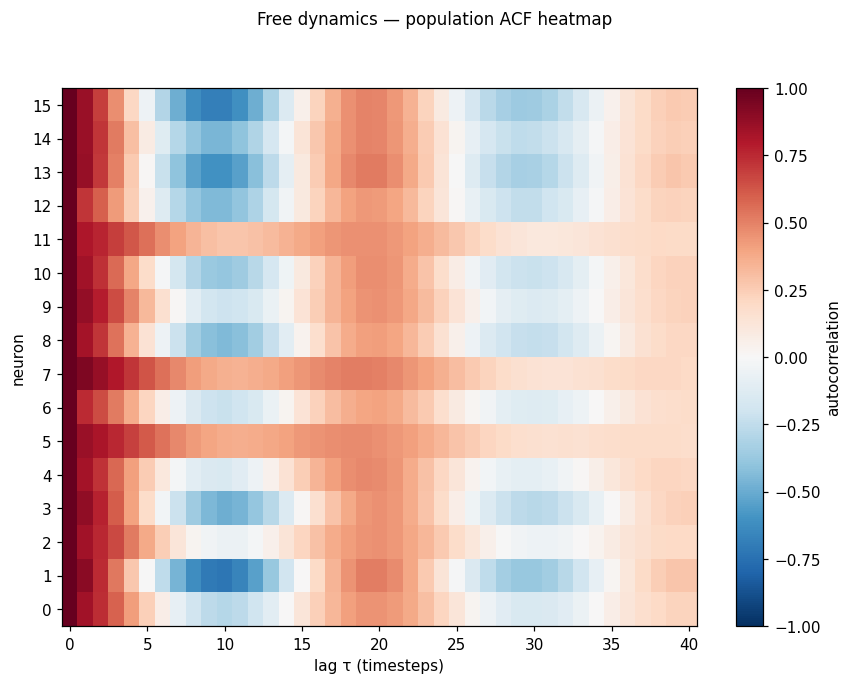

C:\Users\sassa\AppData\Local\Temp\ipykernel_36836\1063110266.py:18: UserWarning: max_lag=40 exceeds T//4=30; the longest lag uses only 80 pairs per trial and the tail of the ACF may be unreliable.
  fig = ill_zero.plot_autocorrelation(max_lag=max_lag, mode='overlay',


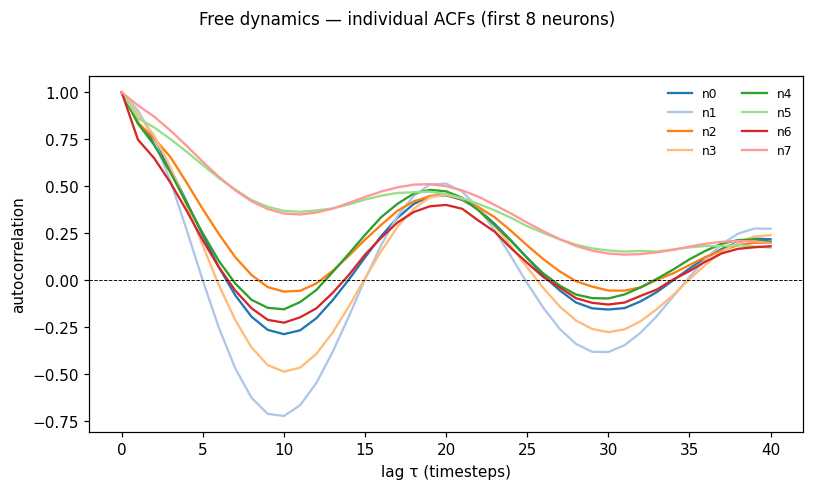

In [7]:
trials_zero = sim.simulate_trials(R_trials, T, U=U_zero)
ill_zero    = Illustrator(trials_zero['y'])

fig = ill_zero.plot_timeseries(show_trials=False,
                               title='Free dynamics — all neurons, trial mean ± 1 SD')
plt.show()

fig = ill_zero.plot_heatmap(zscore=True,
                            title='Free dynamics — population heatmap (z-scored)')
plt.show()

max_lag = min(40, T // 3)
fig = ill_zero.plot_autocorrelation(max_lag=max_lag, mode='heatmap',
                                    title='Free dynamics — population ACF heatmap')
plt.show()

n_acf = min(8, sim.obs_dim)
fig = ill_zero.plot_autocorrelation(max_lag=max_lag, mode='overlay',
                                    neuron_indices=np.arange(n_acf),
                                    title=f'Free dynamics — individual ACFs (first {n_acf} neurons)')
plt.show()

**What to notice:**
- The oscillatory modes produce sinusoidal ripples at the natural period; the decay
  modes produce exponential tails. Both are visible in the ACF as a damped cosine.
- All 16 neurons share the same fundamental time scales — diversity across neurons is
  in amplitude and phase (set by random C), not in frequency content.
- The fast-decaying mode vanishes early; its contribution is visible only in the first
  few timesteps before the slower oscillation dominates.

---
## 3  Pulse Input — Transient vs Sustained Activity

A brief kick at t = 10 deposits energy into the state. Does the system snap back
immediately, or does A carry the excitation forward? The answer depends on which
modes the input activates.

NB we have 2 input channels. Channel 0 is the left column of the B matrix, and Channel 1 is the right column. 



Channel 0 pushes on states 0 and 2, Channel 1 pushes on states 1 and 3. These then gte projected to the 16 neurons through C. 

In [27]:
"""
B = [[1.0  0.0]      row = state 0
     [0.0  1.0]      row = state 1
     [0.5  0.0]      row = state 2
     [0.0  0.5]]     row = state 3
      ↑    ↑
    chan0 chan1
"""

'\nB = [[1.0  0.0]      row = state 0\n     [0.0  1.0]      row = state 1\n     [0.5  0.0]      row = state 2\n     [0.0  0.5]]     row = state 3\n      ↑    ↑\n    chan0 chan1\n'

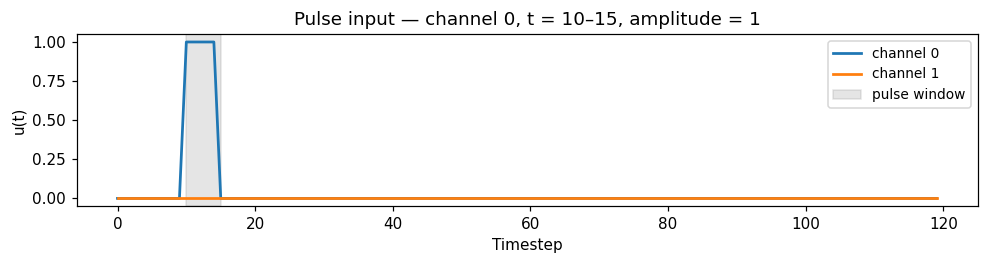

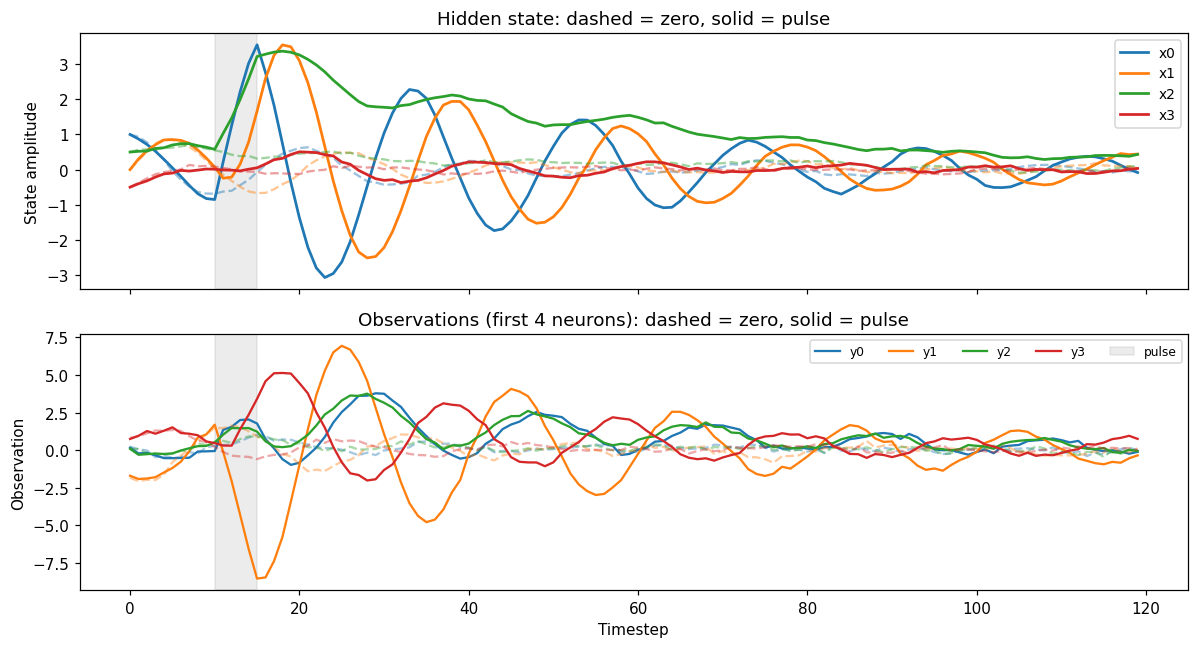

In [8]:
U_pulse = pulse_input(T, sim.input_dim, channel=0, start=10, duration=5, amplitude=1.0)

fig, ax = plt.subplots(figsize=(9, 2.5))
for ch in range(sim.input_dim):
    ax.plot(U_pulse[:, ch], label=f'channel {ch}', lw=1.8)
ax.axvspan(10, 15, color='gray', alpha=0.2, label='pulse window')
ax.set_xlabel('Timestep'); ax.set_ylabel('u(t)')
ax.set_title('Pulse input — channel 0, t = 10–15, amplitude = 1')
ax.legend(fontsize=9); plt.tight_layout(); plt.show()

result_pulse_1 = sim.simulate(T, U=U_pulse)
x_pulse        = result_pulse_1['x'][:-1]

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
for i in range(sim.state_dim):
    axes[0].plot(x_zero[:, i],  ls='--', alpha=0.45, color=f'C{i}')
    axes[0].plot(x_pulse[:, i], lw=1.8,              color=f'C{i}', label=f'x{i}')
axes[0].axvspan(10, 15, color='gray', alpha=0.15)
axes[0].set_ylabel('State amplitude')
axes[0].set_title('Hidden state: dashed = zero, solid = pulse')
axes[0].legend(fontsize=9)

ns = min(4, sim.obs_dim)
for ni in range(ns):
    axes[1].plot(y_zero_1[:, ni],            ls='--', alpha=0.4, color=f'C{ni}')
    axes[1].plot(result_pulse_1['y'][:, ni], lw=1.5,             color=f'C{ni}', label=f'y{ni}')
axes[1].axvspan(10, 15, color='gray', alpha=0.15, label='pulse')
axes[1].set_ylabel('Observation'); axes[1].set_xlabel('Timestep')
axes[1].set_title(f'Observations (first {ns} neurons): dashed = zero, solid = pulse')
axes[1].legend(fontsize=8, ncol=ns + 1)
plt.tight_layout(); plt.show()

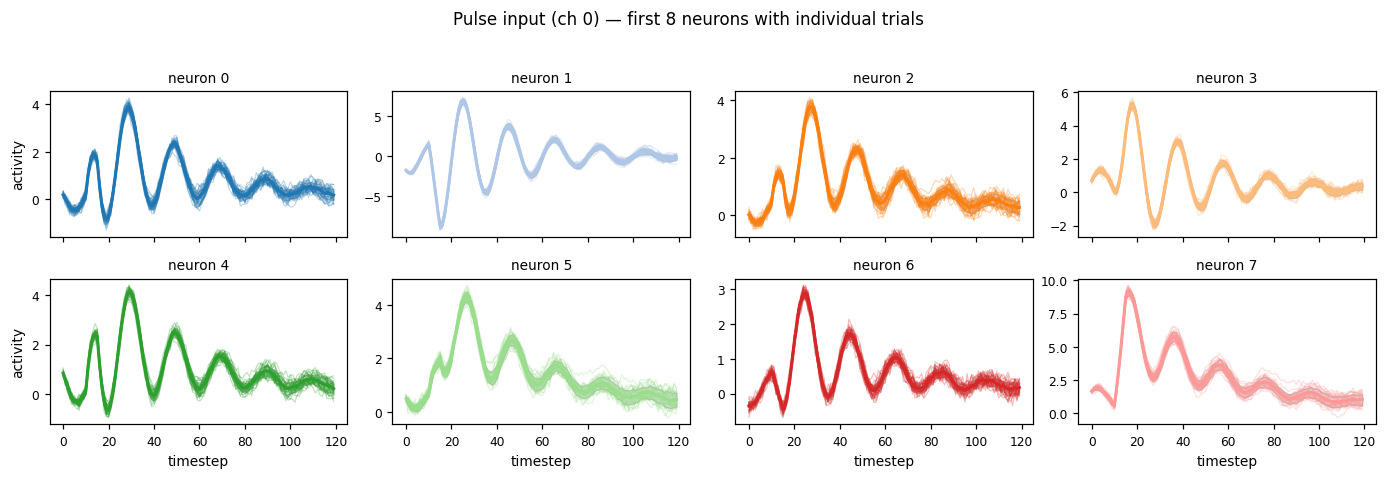

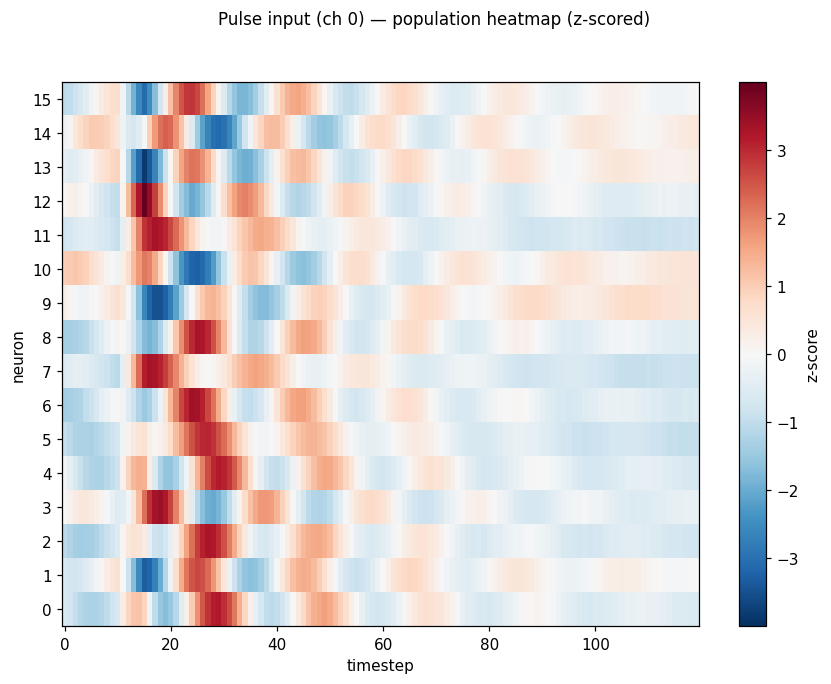

In [9]:
trials_pulse = sim.simulate_trials(R_trials, T, U=U_pulse)
ill_pulse    = Illustrator(trials_pulse['y'])

n_ts = min(8, sim.obs_dim)
fig = ill_pulse.plot_timeseries(show_trials=True, neuron_indices=np.arange(n_ts),
                                title=f'Pulse input (ch 0) — first {n_ts} neurons with individual trials')
plt.show()

fig = ill_pulse.plot_heatmap(zscore=True,
                             title='Pulse input (ch 0) — population heatmap (z-scored)')
plt.show()

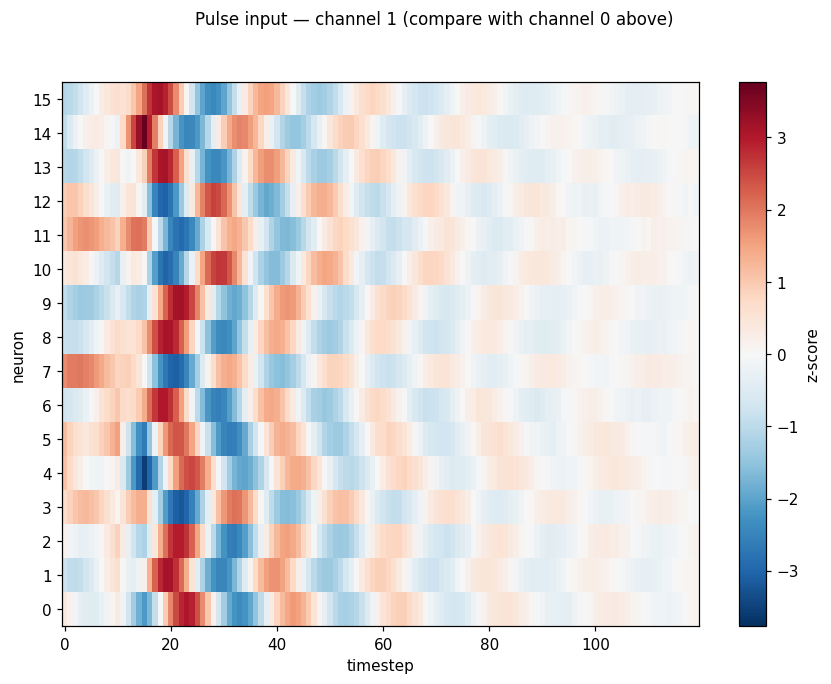

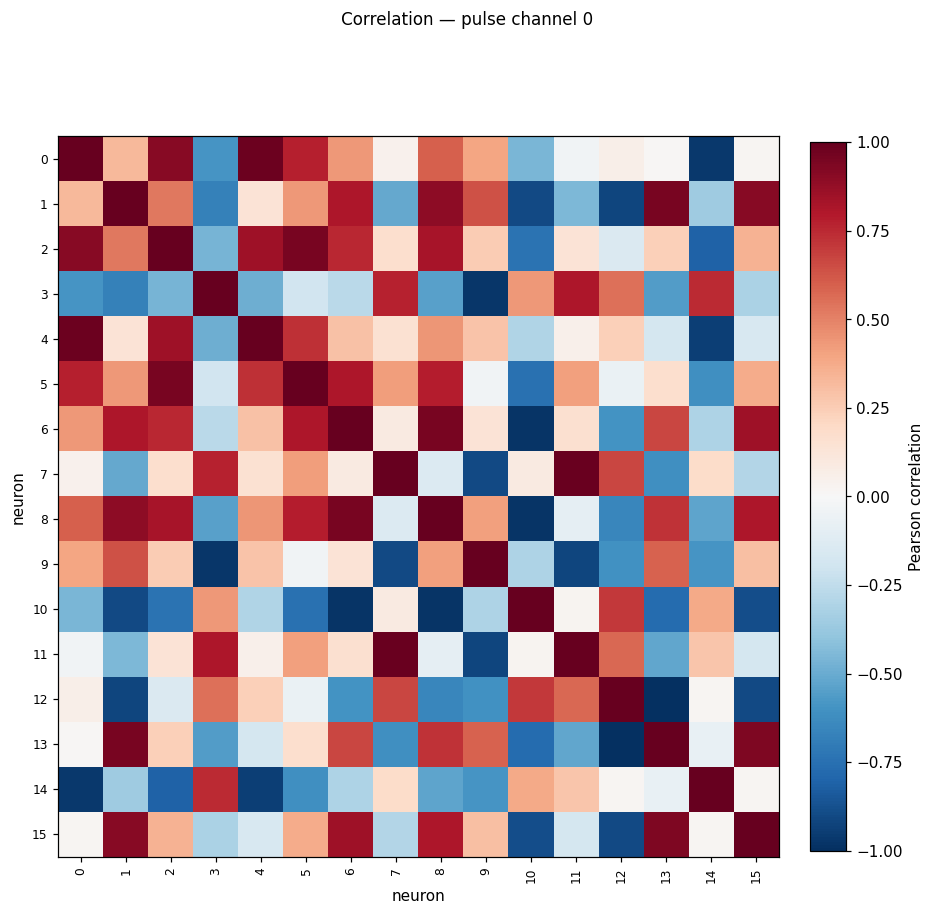

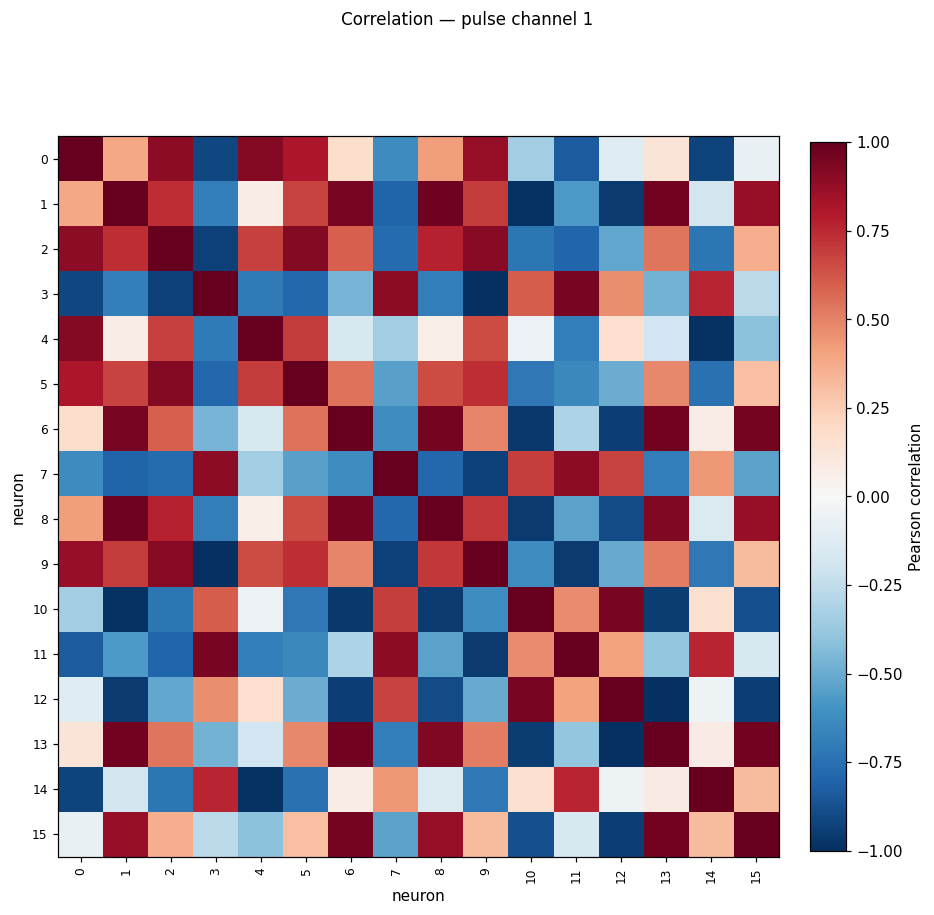

In [10]:
if sim.input_dim > 1:
    U_pulse_ch1   = pulse_input(T, sim.input_dim, channel=1, start=10, duration=5)
    trials_pulse1 = sim.simulate_trials(R_trials, T, U=U_pulse_ch1)
    ill_pulse_ch1 = Illustrator(trials_pulse1['y'])

    fig = ill_pulse_ch1.plot_heatmap(zscore=True,
                                     title='Pulse input — channel 1 (compare with channel 0 above)')
    plt.show()

    C0, fig0 = ill_pulse.plot_correlation_matrix(cluster=False,
                                                  title='Correlation — pulse channel 0')
    plt.show()

    C1, fig1 = ill_pulse_ch1.plot_correlation_matrix(cluster=False,
                                                      title='Correlation — pulse channel 1')
    plt.show()
else:
    print('Only one input channel — skipping channel comparison.')

**What to notice:**
- After the pulse ends, the oscillatory modes *ring on* at the natural period;
  the slow decay mode (|λ| ≈ 0.98) carries the excitation for tens of steps.
- The fast-decaying mode contributes a sharp transient that fades within ~10 steps.
- Channels 0 and 1 produce different spatial patterns across neurons (different columns of B map through C differently - different channels light up different subsets of neurons)
- Both channels produce the same fundamental temporal frequencies - the stripe spacing is roughly 20 timesteps peak-to-peak.

- Even though the 2 channels produce different spatial patterns, they produce almost the same correlation structure.
- Correlation asks "do neurons A and B rise and fall together?" That co-movement is dictated by which latent modes they share through C, and those modes are the same period-20 oscillation either way. Two neurons that both load heavily on the oscillator's first component will go up and down together regardless of which channel was used to excite the oscillator — they'll just oscillate with different overall amplitudes. Correlation normalises out the amplitude, leaving only the co-movement pattern.

  

---
## 4  Sinusoidal Input — Resonance

What happens when the drive frequency matches the system's natural oscillation?
Compare on-resonance, slower, and faster sinusoidal inputs.

C:\Users\sassa\AppData\Local\Temp\ipykernel_36836\1234620659.py:20: UserWarning: max_lag=50 exceeds T//4=30; the longest lag uses only 70 pairs per trial and the tail of the ACF may be unreliable.
  fig = ill.plot_autocorrelation(max_lag=min(50, T // 2), mode='overlay',


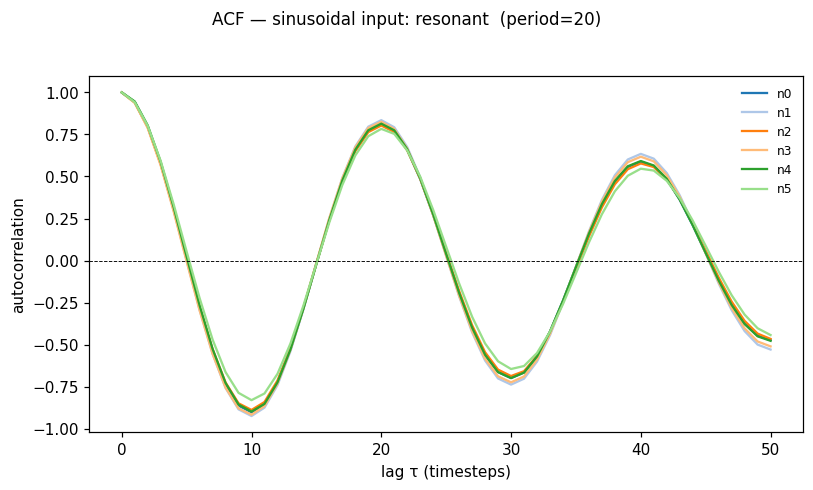

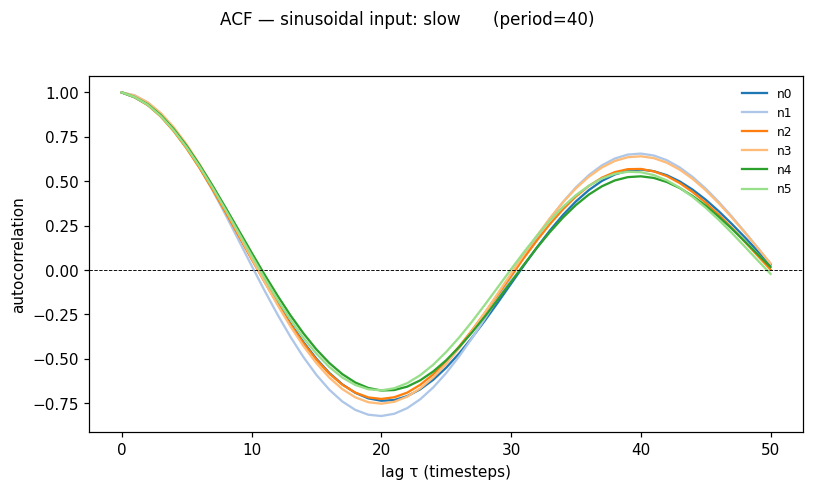

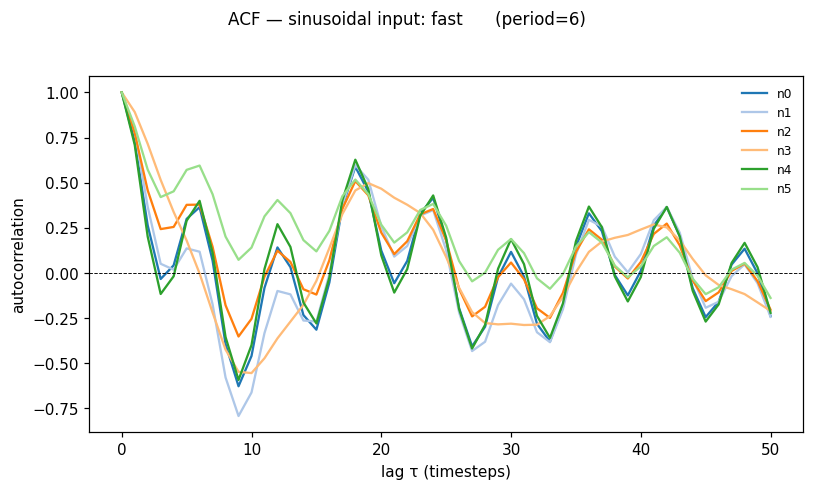

In [11]:
p_slow = nat_period * 2
p_fast = max(4, nat_period // 3)

sin_specs = [
    (f'resonant  (period={nat_period})', float(nat_period)),
    (f'slow      (period={p_slow})',     float(p_slow)),
    (f'fast      (period={p_fast})',     float(p_fast)),
]

n_sin_trials = 20
n_acf_show   = min(6, sim.obs_dim)
illustrators_sin = {}

for label, period in sin_specs:
    U_s    = sinusoidal_input(T, sim.input_dim, amplitude=0.5, period=period)
    trials = sim.simulate_trials(n_sin_trials, T, U=U_s)
    ill    = Illustrator(trials['y'])
    illustrators_sin[label] = ill

    fig = ill.plot_autocorrelation(max_lag=min(50, T // 2), mode='overlay',
                                   neuron_indices=np.arange(n_acf_show),
                                   title=f'ACF — sinusoidal input: {label}')
    plt.show()

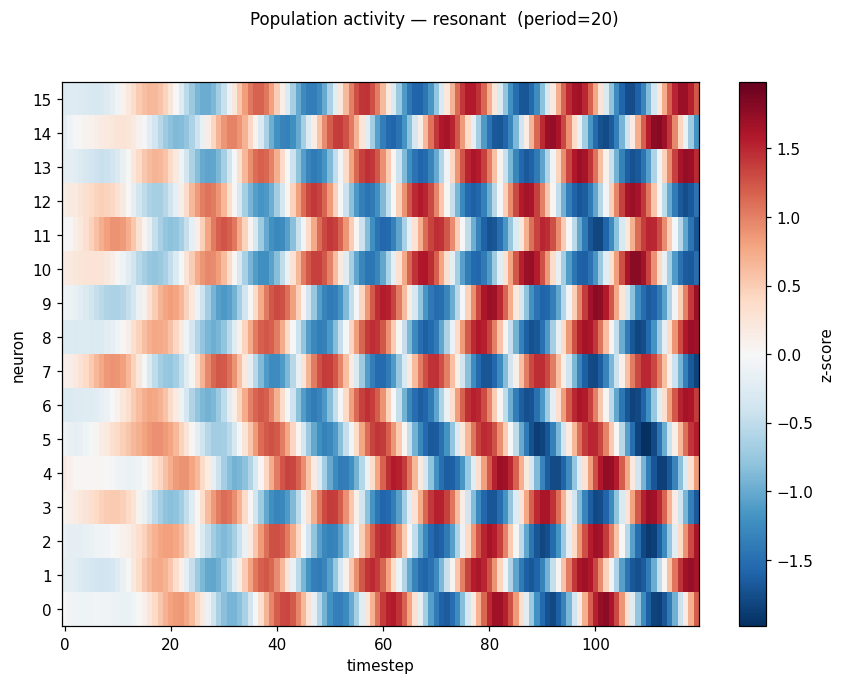

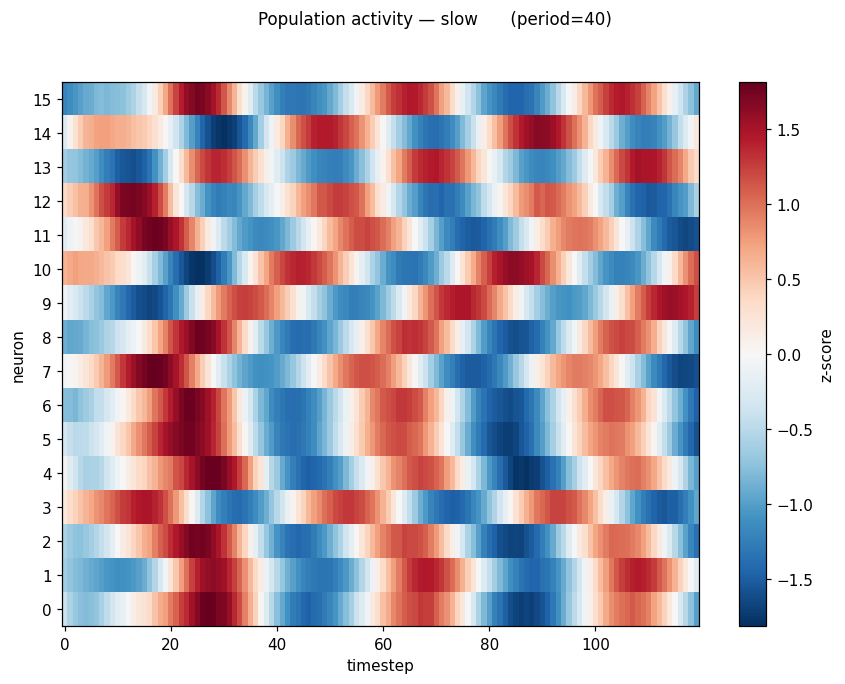

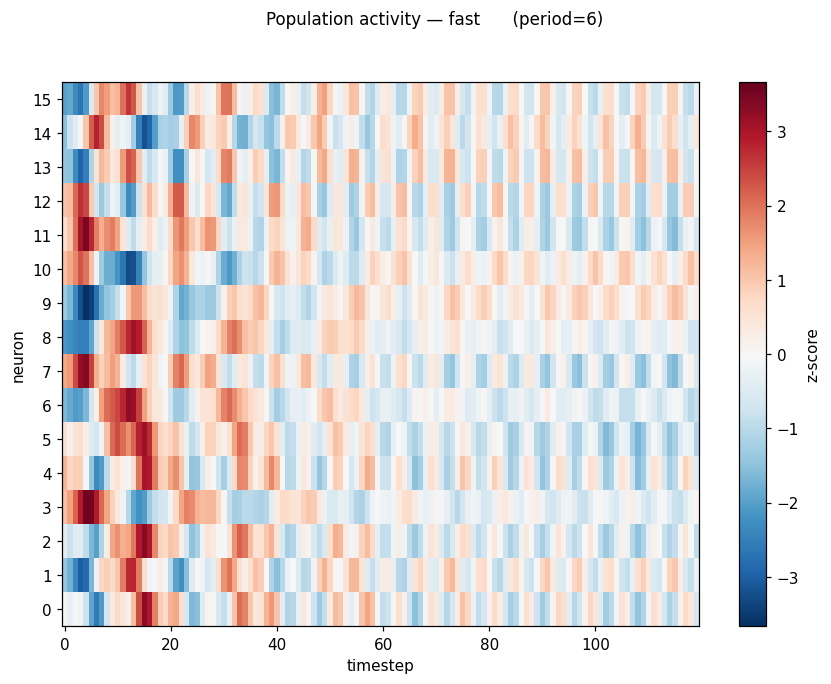

In [12]:
for label, ill in illustrators_sin.items():
    fig = ill.plot_heatmap(zscore=True, title=f'Population activity — {label}')
    plt.show()

**What to notice:**
- On-resonance drive produces the largest steady-state amplitude: A amplifies
  frequencies near its natural pole, even though it cannot produce unbounded growth.
- The ACF under each input inherits *both* the input period and the natural period as
  superimposed oscillations. Under resonant drive they coincide into a single peak.
- The width of the ±1 SD band (trial-to-trial variability) is set by the noise level,
  not the input — but the signal-to-noise ratio changes: a weaker response (off-resonance)
  sits lower above the noise floor.

---
## 5  Random Input — The System as a Filter

White-noise input stimulates all frequencies equally. The system then acts as a
resonant filter, imprinting its eigenstructure on the output. The ACF of y under
white-noise drive reveals the system's impulse-response fingerprint.

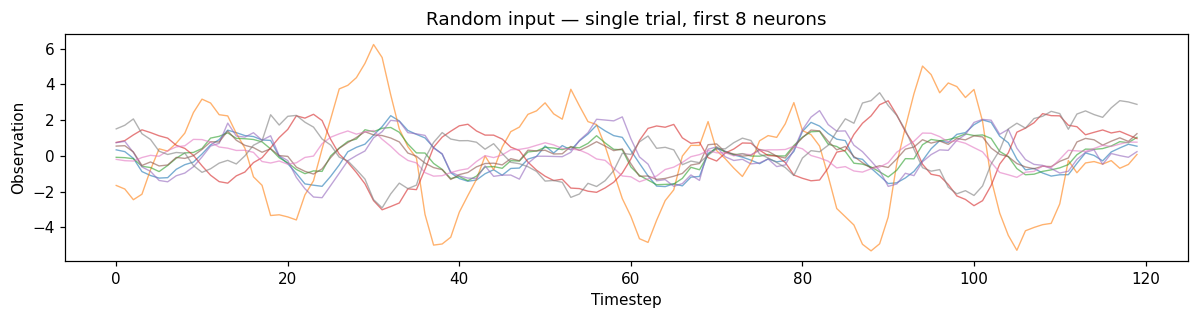

In [13]:
U_rand        = random_input(T, sim.input_dim, amplitude=0.3, seed=99)
result_rand_1 = sim.simulate(T, U=U_rand)

n_rand = min(8, sim.obs_dim)
fig, ax = plt.subplots(figsize=(11, 3))
for ni in range(n_rand):
    ax.plot(result_rand_1['y'][:, ni], alpha=0.6, lw=0.9)
ax.set_xlabel('Timestep'); ax.set_ylabel('Observation')
ax.set_title(f'Random input — single trial, first {n_rand} neurons')
plt.tight_layout(); plt.show()

C:\Users\sassa\AppData\Local\Temp\ipykernel_36836\2433427550.py:4: UserWarning: max_lag=50 exceeds T//4=30; the longest lag uses only 70 pairs per trial and the tail of the ACF may be unreliable.
  fig = ill_rand.plot_autocorrelation(max_lag=min(50, T // 2), mode='heatmap',


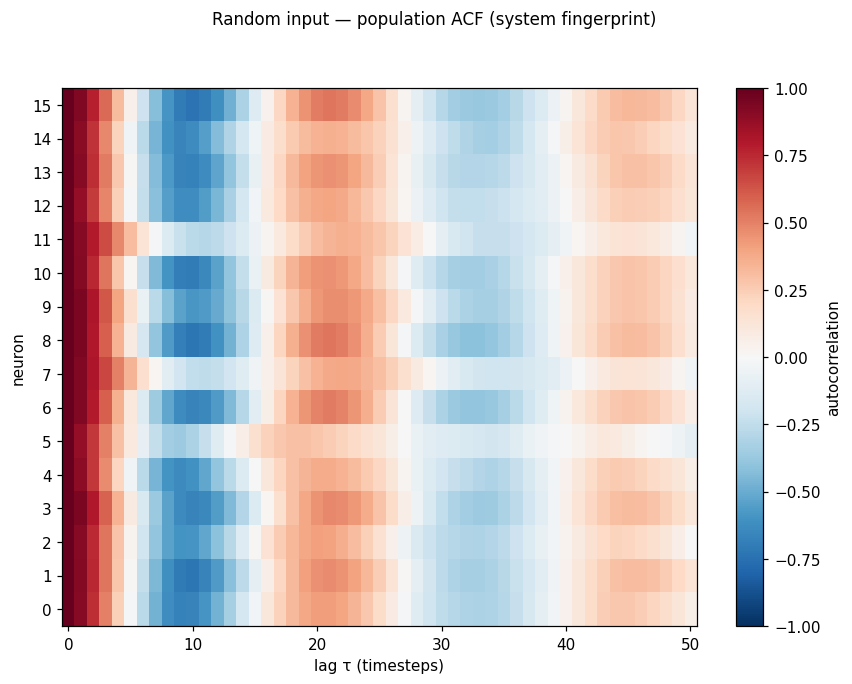

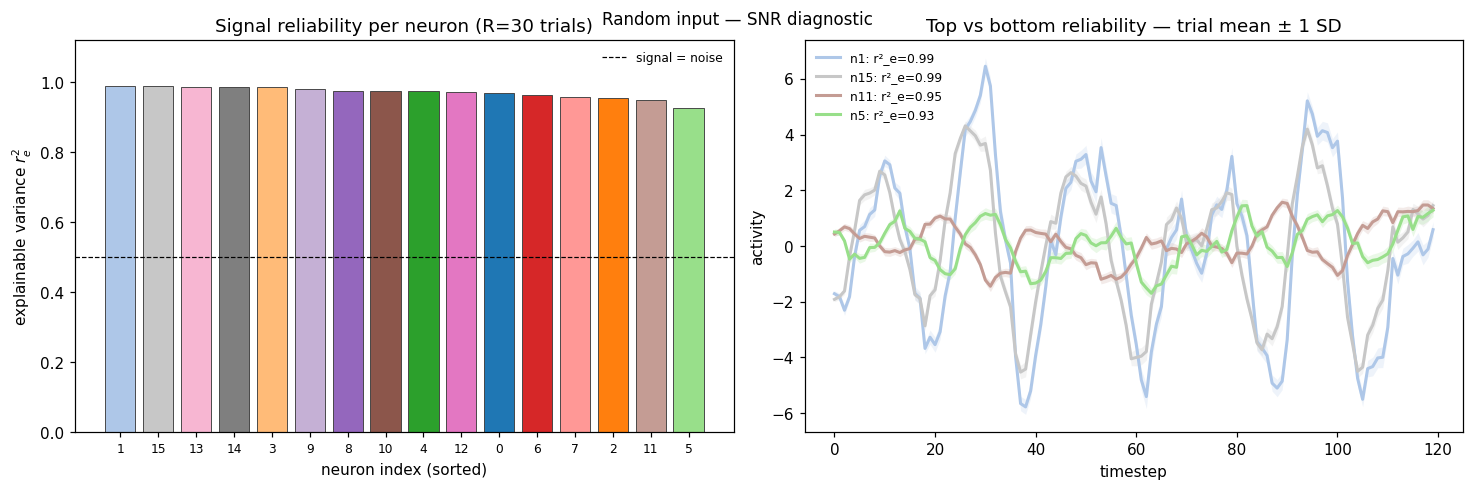

SNR range : 12.734 – 95.918
Neurons with SNR > 1 : 16 / 16


In [14]:
trials_rand = sim.simulate_trials(R_trials, T, U=U_rand)
ill_rand    = Illustrator(trials_rand['y'])

fig = ill_rand.plot_autocorrelation(max_lag=min(50, T // 2), mode='heatmap',
                                    title='Random input — population ACF (system fingerprint)')
plt.show()

snr_rand, fig = ill_rand.compute_snr(plot=True)
fig.suptitle('Random input — SNR diagnostic', fontsize=11)
plt.show()

snr_finite = snr_rand[~np.isnan(snr_rand)]
print(f'SNR range : {snr_finite.min():.3f} – {snr_finite.max():.3f}')
print(f'Neurons with SNR > 1 : {(snr_finite > 1).sum()} / {sim.obs_dim}')

**What to notice:**
- Even under broadband white-noise drive the ACF still shows the natural oscillation
  period — the system is resonant regardless of the input spectrum.
- SNR is generally *lower* than under pulse or sinusoidal input because the signal
  power is spread across all frequencies rather than concentrated.
- This reflects a real experimental trade-off: broadband inputs are good for *system
  identification* (you excite all modes), but reduce per-neuron SNR.

---
## 6  Input-Pathway Fingerprinting

Activating one input channel at a time reveals which neurons each pathway preferentially recruits. Because each column of B projects into the neural population through C differently, a channel sweep produces a spatial fingerprint: a per-neuron mean response that directly identifies the recruited subpopulation. The grouped bar chart below is the actionable view — it shows at a glance which neurons belong to which input pathway.

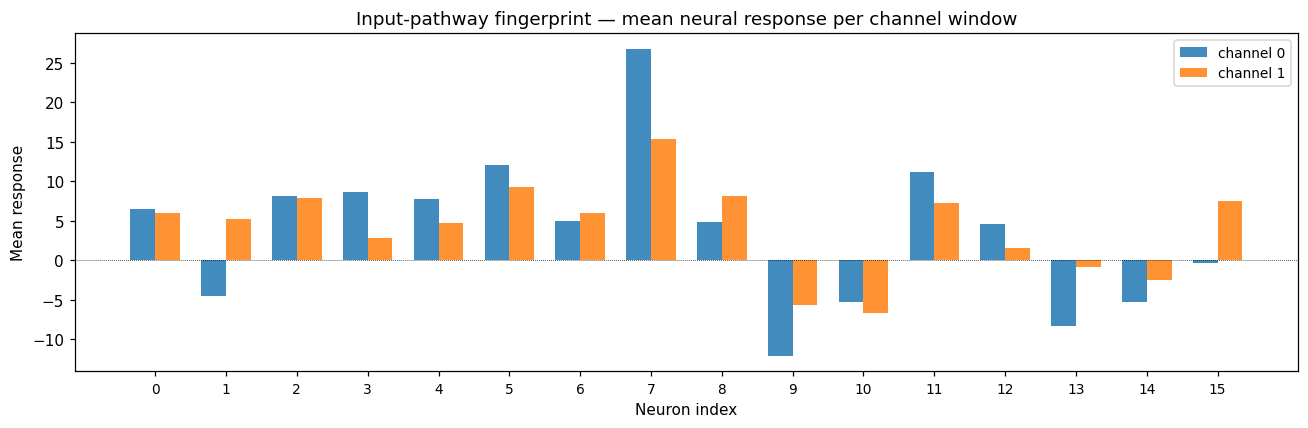

In [33]:
U_sweep      = channel_sweep_input(T, sim.input_dim, amplitude=1.0)
trials_sweep = sim.simulate_trials(25, T, U=U_sweep)

# channel_sweep_input divides T equally: channel k is active in [edges[k], edges[k+1])
n_ch  = sim.input_dim
edges = np.linspace(0, T, n_ch + 1, dtype=int)

mean_per_channel = np.array([
    trials_sweep['y'][:, edges[k]:edges[k+1], :].mean(axis=(0, 1))
    for k in range(n_ch)
])   # (n_ch, obs_dim)

neurons = np.arange(sim.obs_dim)
width   = 0.35
fig, ax = plt.subplots(figsize=(12, 4))
for k in range(n_ch):
    ax.bar(neurons + k * width, mean_per_channel[k], width,
           label=f'channel {k}', alpha=0.85)
ax.set_xticks(neurons + width * (n_ch - 1) / 2)
ax.set_xticklabels([str(n) for n in neurons], fontsize=9)
ax.set_xlabel('Neuron index', fontsize=10)
ax.set_ylabel('Mean response', fontsize=10)
ax.set_title('Input-pathway fingerprint — mean neural response per channel window')
ax.legend(fontsize=9)
ax.axhline(0, color='k', lw=0.5, ls=':')
plt.tight_layout(); plt.show()

**What to notice:**
- Each input channel recruits a distinguishable subset of neurons — the two bars per neuron frequently differ in magnitude and sign.
- This spatial pattern is fixed by how B's column vectors project through C; it is the neural "fingerprint" of the input pathway and does not change across input conditions.
- Experimentally, this procedure identifies which neurons lie downstream of each input pathway without requiring direct knowledge of C — you just stimulate one channel at a time and read off the mean response.

---
## 7  Signal Quality — Per-Neuron SNR

This answers "Are some signals more informative than others?"

The Sahani-Linden bias-corrected SNR separates trial-to-trial signal variance from
noise variance. Here we compare SNR across all four input conditions and examine which
neurons are most vs least informative.

FYI - Sahani–Linden SNR estimates the ratio of reliable signal variance to trial-to-trial noise variance, with a correction term that subtracts the expected leakage of noise into the trial-averaged signal (size: noise variance / number of trials), preventing the upward bias that would otherwise inflate SNR when you have few trials.

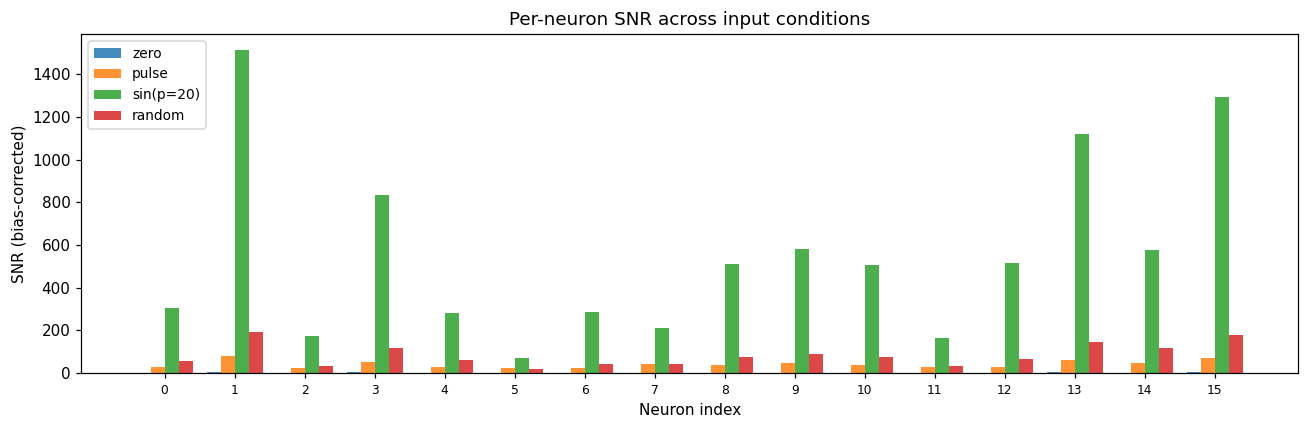

In [28]:
snr_conditions = {
    'zero':              zero_input(T, sim.input_dim),
    'pulse':             pulse_input(T, sim.input_dim, channel=0, start=10, duration=5),
    f'sin(p={nat_period})': sinusoidal_input(T, sim.input_dim, amplitude=0.5,
                                              period=float(nat_period)),
    'random':            random_input(T, sim.input_dim, amplitude=0.3, seed=0),
}

snr_by_cond = {}
for name, U_c in snr_conditions.items():
    t = sim.simulate_trials(R_trials, T, U=U_c)
    ill = Illustrator(t['y'])
    snr_v, _ = ill.compute_snr(plot=False)
    snr_by_cond[name] = snr_v

x_pos = np.arange(sim.obs_dim)
w     = 0.8 / len(snr_by_cond)
fig, ax = plt.subplots(figsize=(12, 4))
for i, (cond, snr_v) in enumerate(snr_by_cond.items()):
    ax.bar(x_pos + i * w, np.nan_to_num(snr_v), w, label=cond, alpha=0.85)
ax.set_xticks(x_pos + w * (len(snr_by_cond) - 1) / 2)
ax.set_xticklabels([str(n) for n in range(sim.obs_dim)], fontsize=8)
ax.set_xlabel('Neuron index')
ax.set_ylabel('SNR (bias-corrected)')
ax.set_title('Per-neuron SNR across input conditions')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

#### Observations

- Resonant sinusoidal input gives much greater SNR. Not shown as clearly in the explainable variance plots.

- Cross neuron variation is huge - SNR depends on how much they weight each of the latent states.


Highest median SNR: condition = "sin(p=20)"


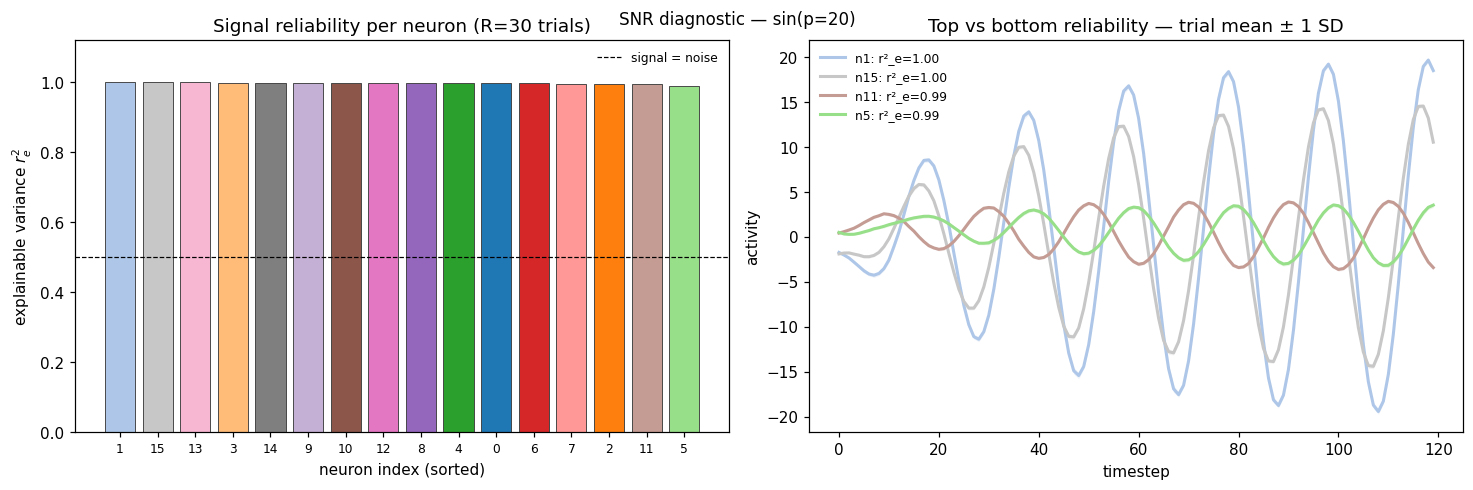

High-SNR neurons: [ 1 15 13  3]
Low-SNR  neurons: [ 5 11  2  7]


In [19]:
best_cond = max(snr_by_cond, key=lambda c: np.nanmedian(snr_by_cond[c]))
print(f'Highest median SNR: condition = "{best_cond}"')

best_trials = sim.simulate_trials(R_trials, T, U=snr_conditions[best_cond])
ill_best    = Illustrator(best_trials['y'])
snr_best, fig = ill_best.compute_snr(plot=True)
fig.suptitle(f'SNR diagnostic — {best_cond}', fontsize=11)
plt.show()

med = np.nanmedian(snr_best)
snr_ranked      = np.nan_to_num(snr_best)
high_snr_neurons = np.argsort(snr_ranked)[::-1][:min(4, sim.obs_dim // 2)]
low_snr_neurons  = np.argsort(snr_ranked)[:min(4, sim.obs_dim // 2)]
print(f'High-SNR neurons: {high_snr_neurons}')
print(f'Low-SNR  neurons: {low_snr_neurons}')

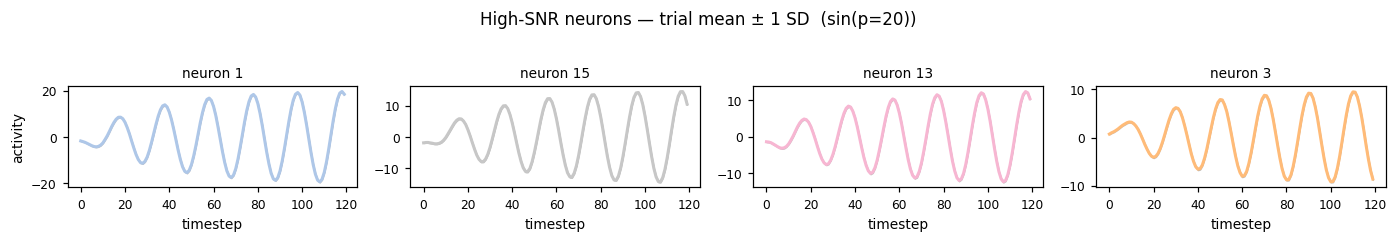

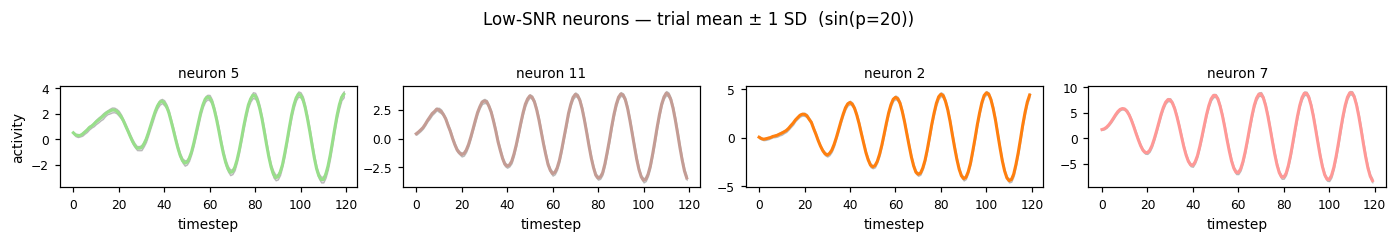

In [20]:
fig = ill_best.plot_timeseries(neuron_indices=high_snr_neurons, show_trials=False,
                               title=f'High-SNR neurons — trial mean ± 1 SD  ({best_cond})')
plt.show()

fig = ill_best.plot_timeseries(neuron_indices=low_snr_neurons, show_trials=False,
                               title=f'Low-SNR neurons — trial mean ± 1 SD  ({best_cond})')
plt.show()

**What to notice:**
- SNR varies widely across neurons even though C is a random projection. Neurons that
  happen to load heavily on high-variance, slowly-decaying modes have far better SNR.
- Sinusoidal and pulse inputs produce higher SNR than zero or random input because they
  continuously replenish the signal; under zero input the signal is exhausted by ~T/2.
- High-SNR neurons show a clean mean with a narrow band; low-SNR neurons look noisy
  even at 30 trials. This has direct implications for downstream filtering (Week 2).

---
## 8  Correlation Structure — Low-Rank Fingerprint

With `obs_dim` neurons driven by `state_dim` latent states, the observation covariance
has at most `state_dim` non-trivial eigenvalues. The correlation matrix eigenspectrum
is a direct read-out of the system's intrinsic dimensionality.

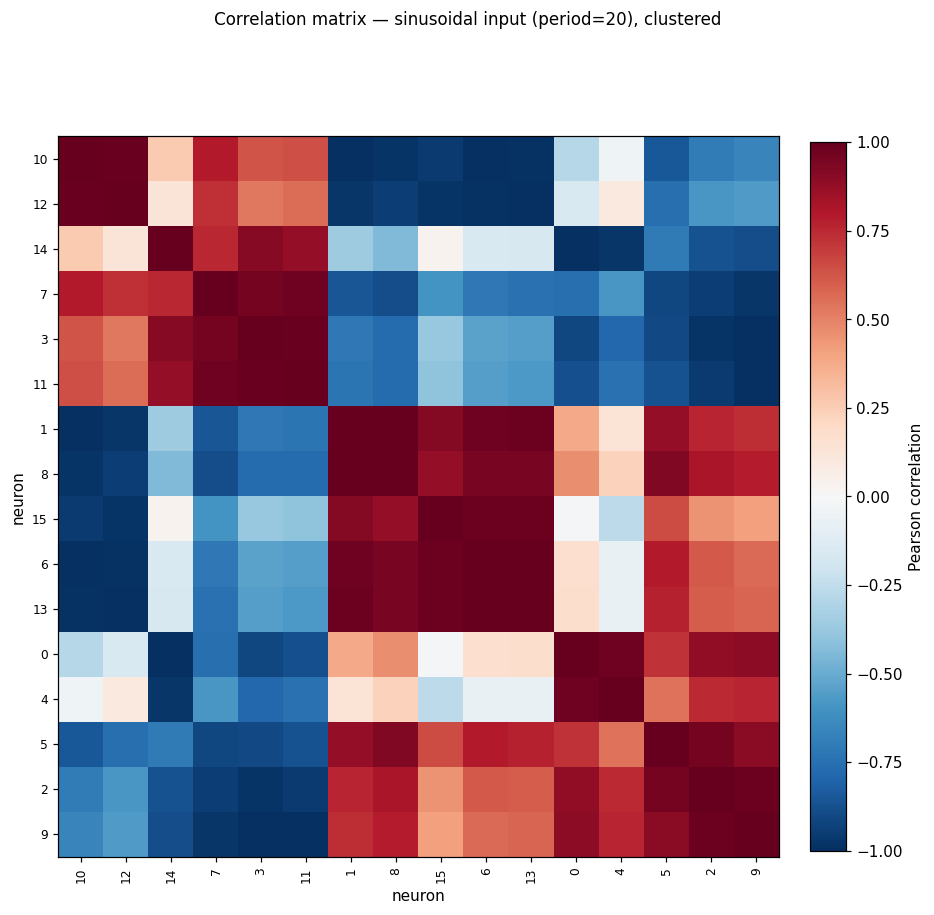

In [21]:
U_sin_res  = sinusoidal_input(T, sim.input_dim, amplitude=0.5, period=float(nat_period))
trials_sin = sim.simulate_trials(R_trials, T, U=U_sin_res)
ill_sin    = Illustrator(trials_sin['y'])

C_mat, fig = ill_sin.plot_correlation_matrix(
    cluster=True,
    title=f'Correlation matrix — sinusoidal input (period={nat_period}), clustered')
plt.show()

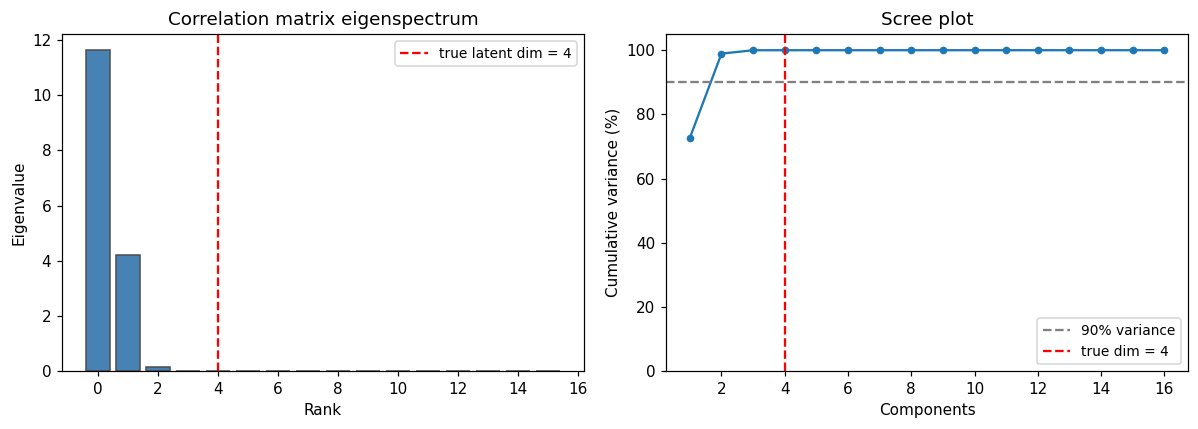

Variance explained by top 4 components: 100.0%


In [32]:
C_uc, _ = ill_sin.plot_correlation_matrix(cluster=False)
plt.close()

eigs   = np.linalg.eigvalsh(C_uc)[::-1]
eigs   = np.clip(eigs, 0, None)
cumvar = np.cumsum(eigs) / eigs.sum()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(range(len(eigs)), eigs, color='steelblue', edgecolor='0.3')
axes[0].axvline(sim.state_dim, color='red', ls='--', lw=1.5,
                label=f'true latent dim = {sim.state_dim}')
axes[0].set_xlabel('Rank'); axes[0].set_ylabel('Eigenvalue')
axes[0].set_title('Correlation matrix eigenspectrum')
axes[0].legend(fontsize=9)

axes[1].plot(range(1, len(cumvar)+1), cumvar * 100, marker='o', ms=4)
axes[1].axhline(90, color='gray', ls='--', label='90% variance')
axes[1].axvline(sim.state_dim, color='red', ls='--',
                label=f'true dim = {sim.state_dim}')
axes[1].set_xlabel('Components'); axes[1].set_ylabel('Cumulative variance (%)')
axes[1].set_title('Scree plot'); axes[1].legend(fontsize=9)
axes[1].set_ylim(0, 105)
plt.tight_layout(); plt.show()

print(f'Variance explained by top {sim.state_dim} components: '
      f'{cumvar[sim.state_dim - 1] * 100:.1f}%')

Effectively only 2 significant dimensions here.

- The two big eigenvalues come from the oscillator. Modes 2 and 3 of A are the complex-conjugate pair forming the period-20 oscillation. Together they have the highest magnitude (|λ| = 0.97) and they're being continuously driven by the resonant input. So most of the energy lives in this 2D oscillating subspace.

- The two tiny modes are barely visible. Mode 0 (|λ| = 0.98, the slow decay) shows up as that small third bar — it's a real mode, but under sinusoidal input nothing keeps replenishing it, so it carries very little variance. Mode 1 (|λ| = 0.75, the fast decay) is buried — half-life of 2.4 steps means it contributes almost nothing to time-averaged variance.

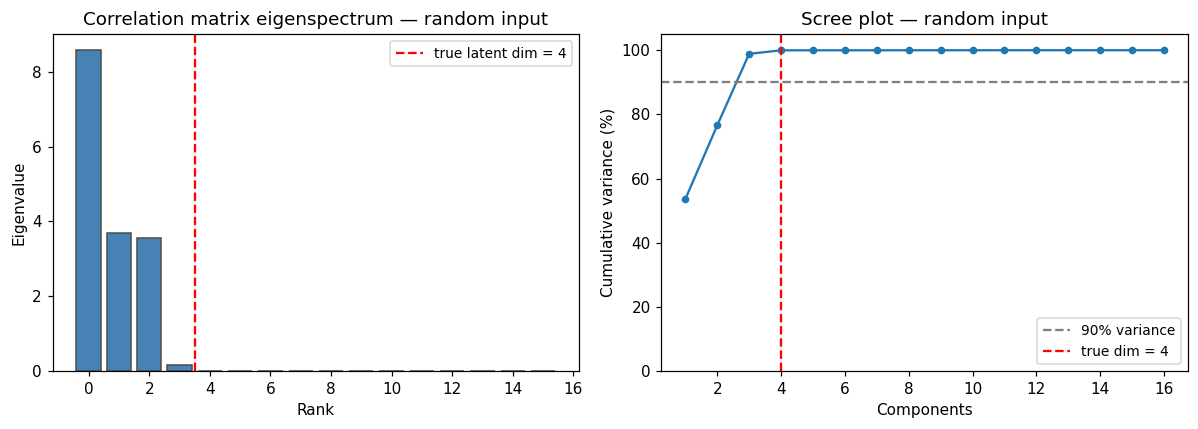

Variance explained by top 4 components: 100.0%
Eigenvalues: [8.575e+00 3.682e+00 3.564e+00 1.740e-01 1.000e-03 1.000e-03]


In [29]:
# Generate random (broadband) input and run trials
U_rand_dim   = random_input(T, sim.input_dim, amplitude=0.3, seed=42)
trials_rand_dim = sim.simulate_trials(R_trials, T, U=U_rand_dim)
ill_rand_dim    = Illustrator(trials_rand_dim['y'])

# Compute the correlation matrix (unclustered, so eigenvalues aren't reordered)
C_uc, _ = ill_rand_dim.plot_correlation_matrix(cluster=False)
plt.close()

eigs   = np.linalg.eigvalsh(C_uc)[::-1]
eigs   = np.clip(eigs, 0, None)
cumvar = np.cumsum(eigs) / eigs.sum()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(range(len(eigs)), eigs, color='steelblue', edgecolor='0.3')
axes[0].axvline(sim.state_dim - 0.5, color='red', ls='--', lw=1.5,
                label=f'true latent dim = {sim.state_dim}')
axes[0].set_xlabel('Rank'); axes[0].set_ylabel('Eigenvalue')
axes[0].set_title('Correlation matrix eigenspectrum — random input')
axes[0].legend(fontsize=9)

axes[1].plot(range(1, len(cumvar)+1), cumvar * 100, marker='o', ms=4)
axes[1].axhline(90, color='gray', ls='--', label='90% variance')
axes[1].axvline(sim.state_dim, color='red', ls='--',
                label=f'true dim = {sim.state_dim}')
axes[1].set_xlabel('Components'); axes[1].set_ylabel('Cumulative variance (%)')
axes[1].set_title('Scree plot — random input'); axes[1].legend(fontsize=9)
axes[1].set_ylim(0, 105)
plt.tight_layout(); plt.show()

print(f'Variance explained by top {sim.state_dim} components: '
      f'{cumvar[sim.state_dim - 1] * 100:.1f}%')
print(f'Eigenvalues: {np.round(eigs[:6], 3)}')

Random input excites all frequencies uniformly.

The fast decay mode is still nearly invisible - fast-decaying modes are easily buried in observation noise.

The dimensionality you measure depends on what you stimulate the system with. If you only ever drive a network at one resonant frequency, you'll underestimate its complexity — you're only sampling the subspace that resonates with your input. Drive it more broadly and the rest of the latent geometry reveals itself.
In real experiments, this is why people often combine multiple stimulus types or use rich, naturalistic inputs when they want to characterise a network's full dimensionality. 

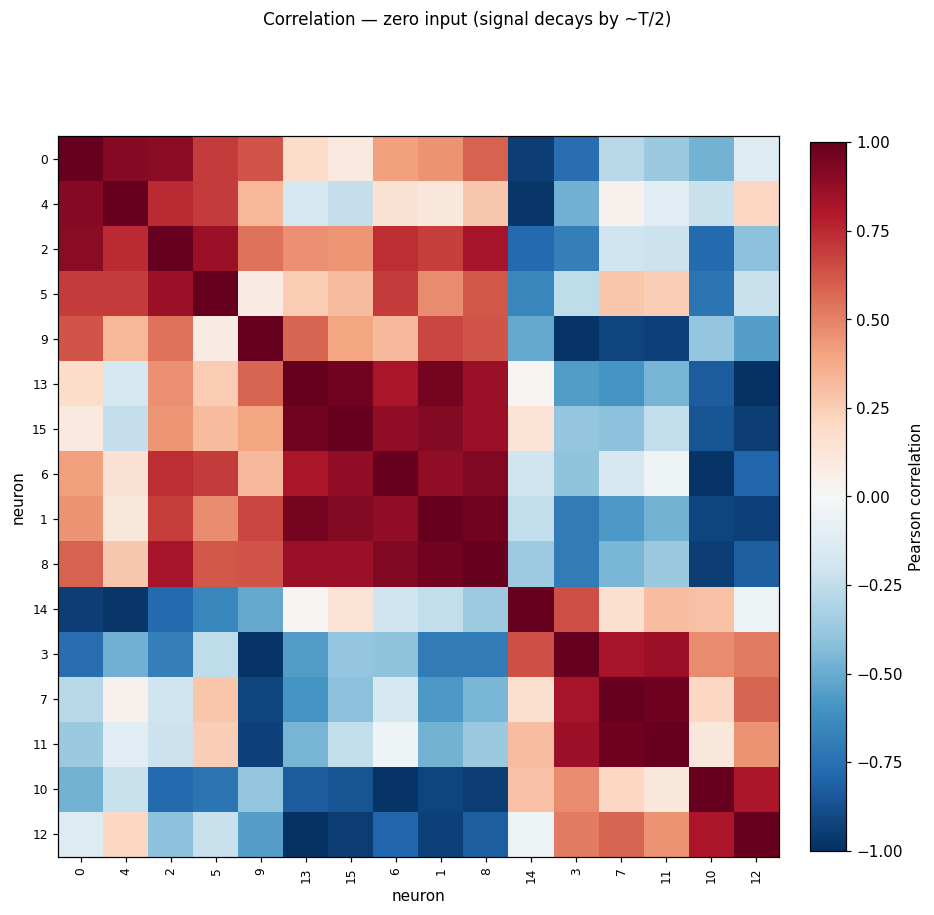

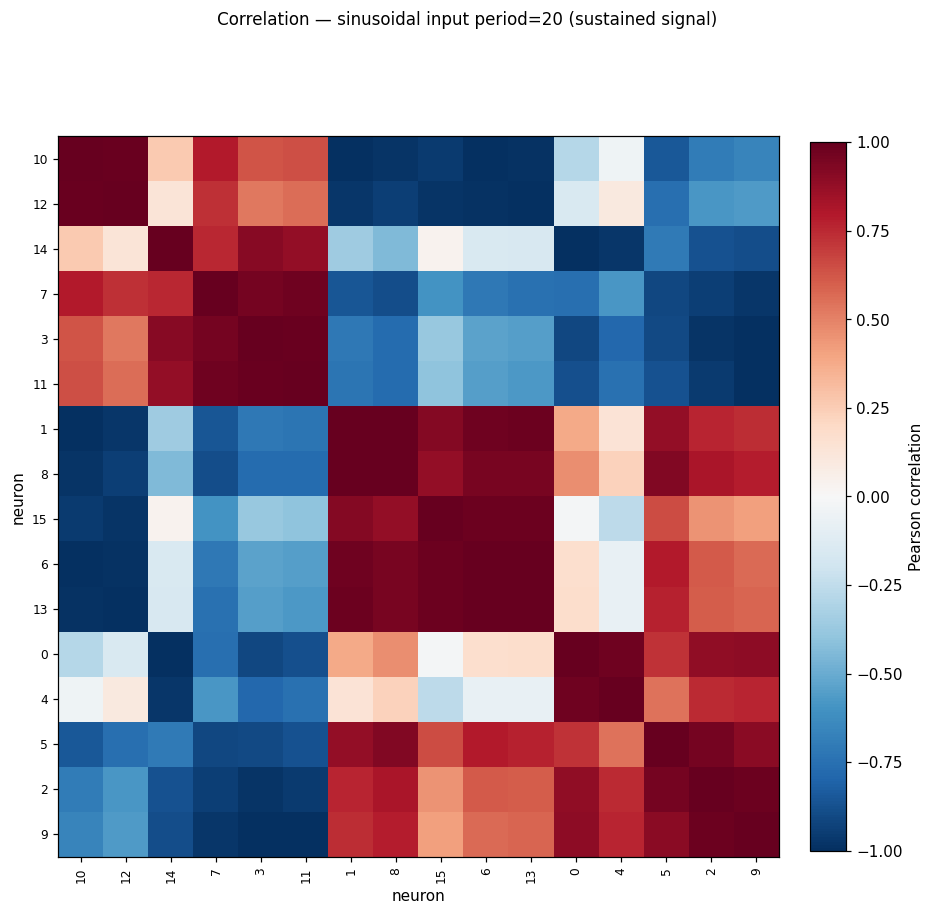

In [23]:
C_zero_mat, fig_z = ill_zero.plot_correlation_matrix(
    cluster=True, title='Correlation — zero input (signal decays by ~T/2)')
plt.show()

C_sin_mat, fig_s = ill_sin.plot_correlation_matrix(
    cluster=True,
    title=f'Correlation — sinusoidal input period={nat_period} (sustained signal)')
plt.show()

#### Takeaways
- Sustained input gives much cleaner correlation structure.



---
## 9  What Can and Cannot Be Recovered?

Synthesising everything above: given only `y(t)` and `u(t)` — never `x(t)` — what
can you recover, and what is fundamentally hidden?

### What is recoverable from y alone

- **Temporal frequencies** (oscillation period, decay time constants): encoded in the
  ACF of y for any full-rank C.
- **Shared population structure**: the low-rank correlation matrix approximates the
  latent dimensionality; PCA recovers a rotated version of the state basis.
- **Input-pathway fingerprints**: the channel sweep reveals which neurons respond to
  which input channel.

### What is difficult or impossible to recover directly

- **Absolute scale and orientation of x**: C mixes the states into all neurons;
  observations identify the state only up to a linear transformation.
- **Fast-decaying modes**: the mode with the smallest |λ| contributes little to
  time-averaged statistics and is easily buried in observation noise.
- **Single-timestep x**: individual y observations are corrupted by R noise. Recovering
  x(t) from a single trial requires filtering across time — exactly what the
  **Kalman filter (Week 2)** provides.

---
*'Fully observable' is a binary guarantee for infinite noiseless data. The Gramian
condition number quantifies how hard the problem is in practice.*